# Machine Learning Foundation

## Course 3, Part c: Support Vector Machines DEMO


## Introduction

We will be using the wine quality data set for these exercises. This data set contains various chemical properties of wine, such as acidity, sugar, pH, and alcohol. It also contains a quality metric (3-9, with highest being better) and a color (red or white). The name of the file is `Wine_Quality_Data.csv`.


In [1]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn

In [2]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

## Part 1: Setup

* Import the data.
* Create the target variable `y` as a 1/0 column where 1 means red.
* Create a `pairplot` for the dataset.
* Create a bar plot showing the correlations between each column and `y`
* Pick the most 2 correlated fields (using the absolute value of correlations) and create `X`
* Use MinMaxScaler to scale `X`. Note that this will output a np.array. Make it a DataFrame again and rename the columns appropriately.


In [3]:
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML241EN-SkillsNetwork/labs/datasets/Wine_Quality_Data.csv", sep=',')


In [4]:
y = (data['color'] == 'red').astype(int)
fields = list(data.columns[:-1])  # everything except "color"
correlations = data[fields].corrwith(y)
correlations.sort_values(inplace=True)
correlations

total_sulfur_dioxide   -0.700357
free_sulfur_dioxide    -0.471644
residual_sugar         -0.348821
citric_acid            -0.187397
quality                -0.119323
alcohol                -0.032970
pH                      0.329129
density                 0.390645
fixed_acidity           0.486740
sulphates               0.487218
chlorides               0.512678
volatile_acidity        0.653036
dtype: float64

In [5]:
sns.set_context('talk')
#sns.set_palette(palette)
sns.set_style('white')

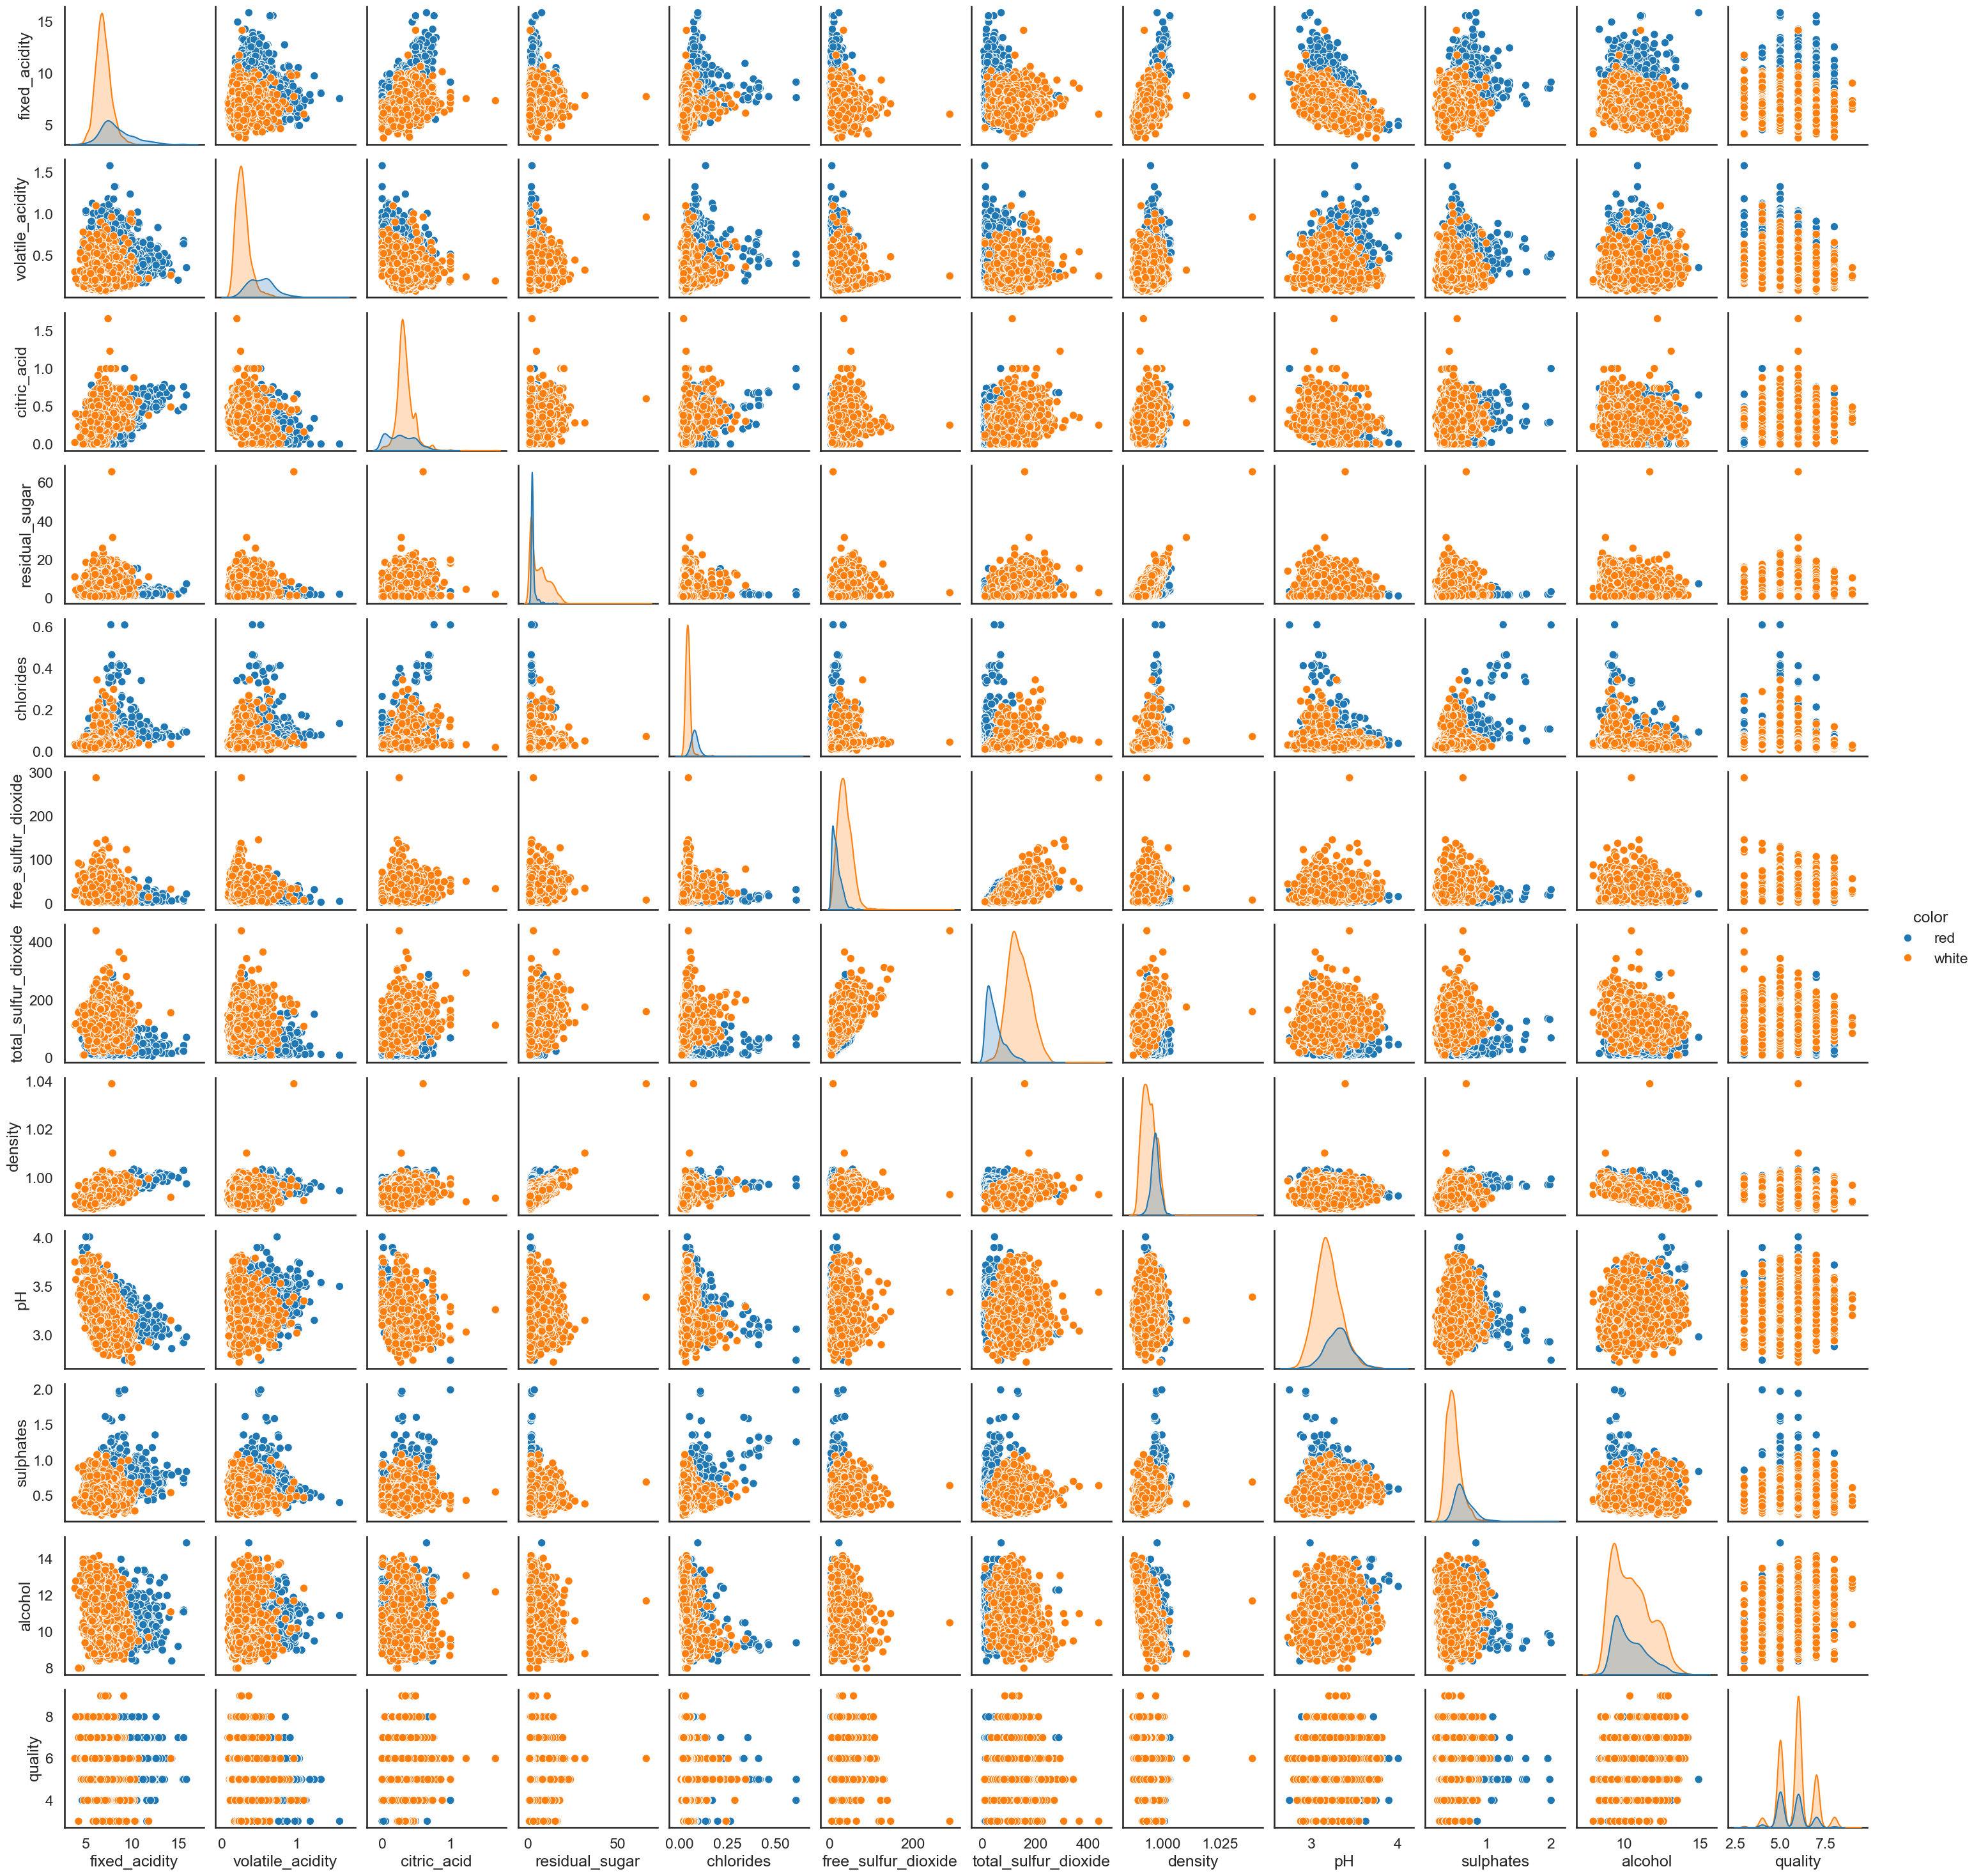

In [6]:
sns.pairplot(data, hue='color')

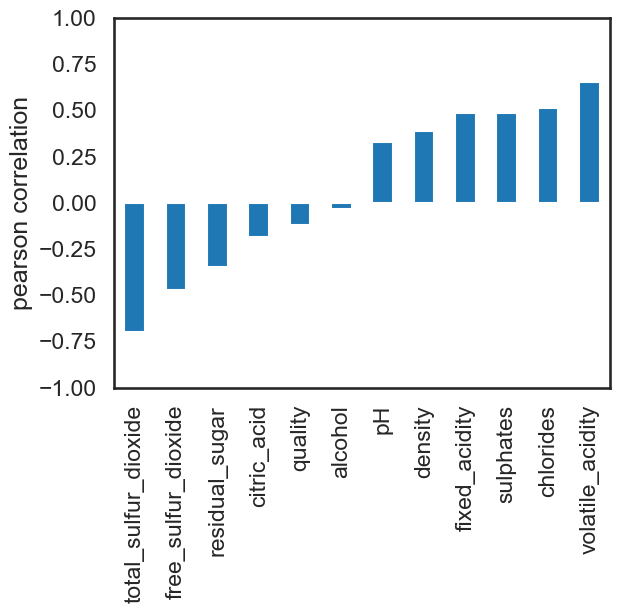

In [7]:
ax = correlations.plot(kind='bar')
ax.set(ylim=[-1, 1], ylabel='pearson correlation');

In [ ]:
from sklearn.preprocessing import MinMaxScaler

fields = correlations.map(abs).sort_values().iloc[-2:].index #保留最高2个
print(fields)
X = data[fields]
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X = pd.DataFrame(X, columns=['%s_scaled' % fld for fld in fields])
print(X.columns)

Index(['volatile_acidity', 'total_sulfur_dioxide'], dtype='object')
Index(['volatile_acidity_scaled', 'total_sulfur_dioxide_scaled'], dtype='object')


## Part 2: Linear Decision Boundary

Our goal is to look at the decision boundary of a LinearSVC classifier on this dataset. Check out [this example](https://scikit-learn.org/stable/auto_examples/svm/plot_iris_svc.html#sphx-glr-auto-examples-svm-plot-iris-svc-py) in sklearn's documentation. 

* Fit a Linear Support Vector Machine Classifier to `X`, `y`.
* Pick 300 samples from `X`. Get the corresponding `y` value. Store them in variables `X_color` and `y_color`. This is because original dataset is too large and it produces a crowded plot.
* Modify `y_color` so that it has the value "red" instead of 1 and 'yellow' instead of 0.
* Scatter plot X_color's columns. Use the keyword argument "color=y_color" to color code samples.
* Use the code snippet below to plot the decision surface in a color coded way.

```python
x_axis, y_axis = np.arange(0, 1, .005), np.arange(0, 1, .005)
xx, yy = np.meshgrid(x_axis, y_axis)
xx_ravel = xx.ravel()
yy_ravel = yy.ravel()
X_grid = pd.DataFrame([xx_ravel, yy_ravel]).T
y_grid_predictions = *[YOUR MODEL]*.predict(X_grid)
y_grid_predictions = y_grid_predictions.reshape(xx.shape)
ax.contourf(xx, yy, y_grid_predictions, cmap=colors, alpha=.3)
```

With LinearSVC, it is easy to experiment with different parameter choices and see the decision boundary.


这段代码是使用 `sklearn.svm.LinearSVC` 构建一个**线性支持向量机（Linear SVM）分类器**，并在二维空间中可视化其**决策边界**的一个完整流程。下面逐段解释每一部分的作用：

---

### 🧠 **模型训练**

```python
from sklearn.svm import LinearSVC

LSVC = LinearSVC()
LSVC.fit(X, y)
```

- **`LinearSVC`**：线性支持向量分类器。适用于特征和目标变量之间存在线性可分关系的情况。
- **`fit(X, y)`**：在训练数据 `X` 和标签 `y` 上训练模型。

---

### 🎨 **可视化样本点**

```python
X_color = X.sample(300, random_state=45)
y_color = y.loc[X_color.index]
y_color = y_color.map(lambda r: 'red' if r == 1 else 'yellow')
```

- **从 `X` 中随机抽样 300 个点**用于可视化。
- **根据标签 `y` 映射颜色**：如果标签为 1，点为红色；否则为黄色。

```python
ax = plt.axes()
ax.scatter(
    X_color.iloc[:, 0], X_color.iloc[:, 1],
    color=y_color, alpha=1)
```

- **绘制散点图**：使用前两个特征作为横轴和纵轴，颜色表示类别。

---

### 🧭 **生成网格数据，预测并绘制决策边界**

```python
x_axis, y_axis = np.arange(0, 1.005, .005), np.arange(0, 1.005, .005)
xx, yy = np.meshgrid(x_axis, y_axis)
```

- 创建了一个从 `[0, 1]` 坐标系的网格，用于画决策边界。

```python
xx_ravel = xx.ravel()
yy_ravel = yy.ravel()
X_grid = pd.DataFrame([xx_ravel, yy_ravel]).T
```

- 将网格坐标展平，构建预测输入 `X_grid`。

```python
y_grid_predictions = LSVC.predict(X_grid)
y_grid_predictions = y_grid_predictions.reshape(xx.shape)
```

- 对网格上的每个点进行预测，并重新 reshape 成原网格形状，用于画等高线。

```python
ax.contourf(xx, yy, y_grid_predictions, cmap=plt.cm.autumn_r, alpha=.3)
```

- **绘制决策区域**：用不同颜色阴影表示模型预测为不同类别的区域。

---

### 🧾 **设置图像属性**

```python
ax.set(
    xlabel=fields[0],
    ylabel=fields[1],
    xlim=[0, 1],
    ylim=[0, 1],
    title='decision boundary for LinearSVC');
```

- 设置坐标轴标签、范围和标题。`fields` 是前面两个特征的名称，假设你是在二维特征空间上画图。

---

### ✅ 总结：

你最终得到一个图：
- 背景颜色区分模型预测的分类区域（决策边界）
- 前景散点图显示训练数据点及其实际标签颜色
- 帮助直观了解 `LinearSVC` 是如何划分数据空间的

---

如果你想试着在自己的数据上做类似的可视化，只需要把 `X` 和 `y` 换成你的数据，并确认前两列是可视化的两个特征即可。

需要我帮你改造成适配你自己的数据代码吗？

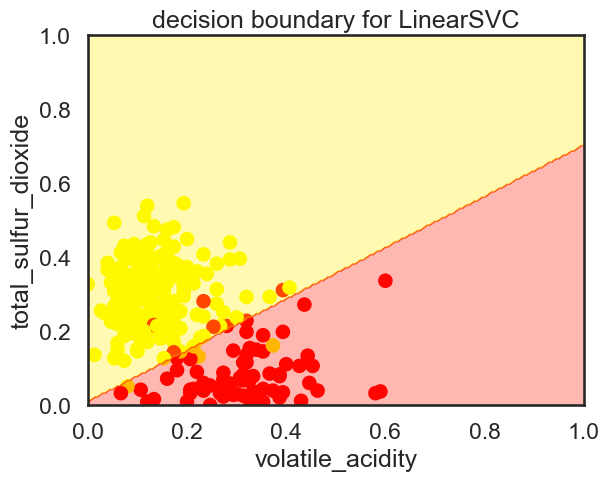

In [9]:
from sklearn.svm import LinearSVC

LSVC = LinearSVC()
LSVC.fit(X, y)

X_color = X.sample(300, random_state=45)
y_color = y.loc[X_color.index]
y_color = y_color.map(lambda r: 'red' if r == 1 else 'yellow')
ax = plt.axes()
ax.scatter(
    X_color.iloc[:, 0], X_color.iloc[:, 1],
    color=y_color, alpha=1)
# -----------
x_axis, y_axis = np.arange(0, 1.005, .005), np.arange(0, 1.005, .005)
xx, yy = np.meshgrid(x_axis, y_axis)
xx_ravel = xx.ravel()
yy_ravel = yy.ravel()
X_grid = pd.DataFrame([xx_ravel, yy_ravel]).T
y_grid_predictions = LSVC.predict(X_grid)
y_grid_predictions = y_grid_predictions.reshape(xx.shape)
ax.contourf(xx, yy, y_grid_predictions, cmap=plt.cm.autumn_r, alpha=.3)
# -----------
ax.set(
    xlabel=fields[0],
    ylabel=fields[1],
    xlim=[0, 1],
    ylim=[0, 1],
    title='decision boundary for LinearSVC');

## Part 3: Gaussian Kernel

Let's now fit a Gaussian kernel SVC and see how the decision boundary changes.

* Consolidate the code snippets in Question 2 into one function which takes in an estimator, `X` and `y`, and produces the final plot with decision boundary. The steps are:
    <ol>
     <li> Fit model
     <li> Get sample 300 records from X and the corresponding y's
     <li> Create grid, predict, plot using ax.contourf
     <li> Add on the scatter plot
    </ol>
* After copying and pasting code, the finished function uses the input `estimator` and not the LinearSVC model.
* For the following values of `gamma`, create a Gaussian Kernel SVC and plot the decision boundary.  
`gammas = [.5, 1, 2, 10]`
* Holding `gamma` constant, we plot the decision boundary for various values of `C`: 
`[.1, 1, 10]`


你的函数 `plot_decision_boundary` 非常清晰，已经成功将线性或其他支持二维特征输入的分类器的决策边界可视化。下面是对这个函数的逐步讲解以及可以优化的一点点建议：

---

### ✅ **函数功能总结**

```python
def plot_decision_boundary(estimator, X, y):
```
- **输入**：
  - `estimator`：任意实现了 `.fit()` 和 `.predict()` 接口的分类器（比如 `LinearSVC`、`LogisticRegression`、`DecisionTreeClassifier` 等）
  - `X`：特征（前两列为 2D 平面绘图用）
  - `y`：标签（0 或 1）

---

### 🧠 **训练模型**

```python
    estimator.fit(X, y)
```
- 在传入的 `X, y` 上训练模型。

---

### 🎨 **采样点着色**

```python
    X_color = X.sample(300)
    y_color = y.loc[X_color.index]
    y_color = y_color.map(lambda r: 'red' if r == 1 else 'yellow')
```
- 随机从数据中采样 300 个点用于散点图展示，按类别映射成红色或黄色。

---

### 📐 **生成决策网格**

```python
    x_axis, y_axis = np.arange(0, 1, .005), np.arange(0, 1, .005)
    xx, yy = np.meshgrid(x_axis, y_axis)
    xx_ravel = xx.ravel()
    yy_ravel = yy.ravel()
    X_grid = pd.DataFrame([xx_ravel, yy_ravel]).T
```
- 构建二维平面网格坐标，用于向模型输入一大批点预测其类别。
- 默认只支持 `[0, 1]` 范围内的图像。

---

### 🔮 **预测网格上的类别**

```python
    y_grid_predictions = estimator.predict(X_grid)
    y_grid_predictions = y_grid_predictions.reshape(xx.shape)
```
- 对网格点分类，并 reshape 为原来的网格形状，便于等高线绘图。

---

### 🖼️ **绘图**

```python
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.contourf(xx, yy, y_grid_predictions, cmap=plt.cm.autumn_r, alpha=.3)
    ax.scatter(X_color.iloc[:, 0], X_color.iloc[:, 1], color=y_color, alpha=1)
    ax.set(
        xlabel=fields[0],
        ylabel=fields[1],
        title=str(estimator))
```

- 使用 `contourf` 绘制决策区域
- 使用 `scatter` 绘制采样点，显示其真实类别
- `xlabel` 和 `ylabel` 取自全局变量 `fields`，这可能会导致函数不够通用

---

### ✅ 建议优化（可选）

1. **参数中加入 `fields`，避免依赖全局变量：**

```python
def plot_decision_boundary(estimator, X, y, fields=None):
    ...
    ax.set(
        xlabel=fields[0] if fields else 'Feature 1',
        ylabel=fields[1] if fields else 'Feature 2',
        title=str(estimator))
```

2. **动态确定 `X` 的边界范围：**

现在你写死了 `[0, 1]`，可以根据 `X` 的最小最大值自动设定：

```python
    x_min, x_max = X.iloc[:, 0].min() - 0.05, X.iloc[:, 0].max() + 0.05
    y_min, y_max = X.iloc[:, 1].min() - 0.05, X.iloc[:, 1].max() + 0.05
    x_axis = np.arange(x_min, x_max, 0.005)
    y_axis = np.arange(y_min, y_max, 0.005)
```

---

### ✨ 示例调用（如果你已经定义了 `fields` 和 `X, y`）

```python
plot_decision_boundary(LinearSVC(), X, y, fields=['sepal length', 'sepal width'])
```

---

如果你有进一步需求，比如支持多类分类器，或者非线性模型、绘制概率曲面等，我也可以帮你扩展这个函数。需要吗？

In [10]:
def plot_decision_boundary(estimator, X, y):
    estimator.fit(X, y)
    X_color = X.sample(300)
    y_color = y.loc[X_color.index]
    y_color = y_color.map(lambda r: 'red' if r == 1 else 'yellow')
    x_axis, y_axis = np.arange(0, 1, .005), np.arange(0, 1, .005)
    xx, yy = np.meshgrid(x_axis, y_axis)
    xx_ravel = xx.ravel()
    yy_ravel = yy.ravel()
    X_grid = pd.DataFrame([xx_ravel, yy_ravel]).T
    y_grid_predictions = estimator.predict(X_grid)
    y_grid_predictions = y_grid_predictions.reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.contourf(xx, yy, y_grid_predictions, cmap=plt.cm.autumn_r, alpha=.3)
    ax.scatter(X_color.iloc[:, 0], X_color.iloc[:, 1], color=y_color, alpha=1)
    ax.set(
        xlabel=fields[0],
        ylabel=fields[1],
        title=str(estimator))

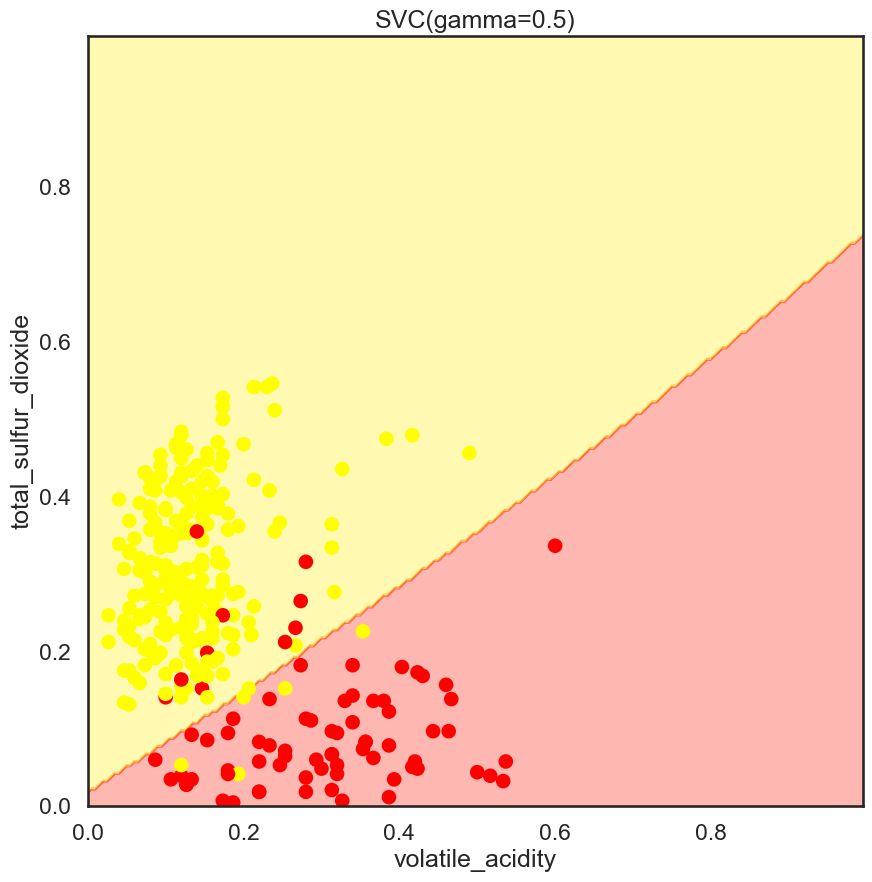

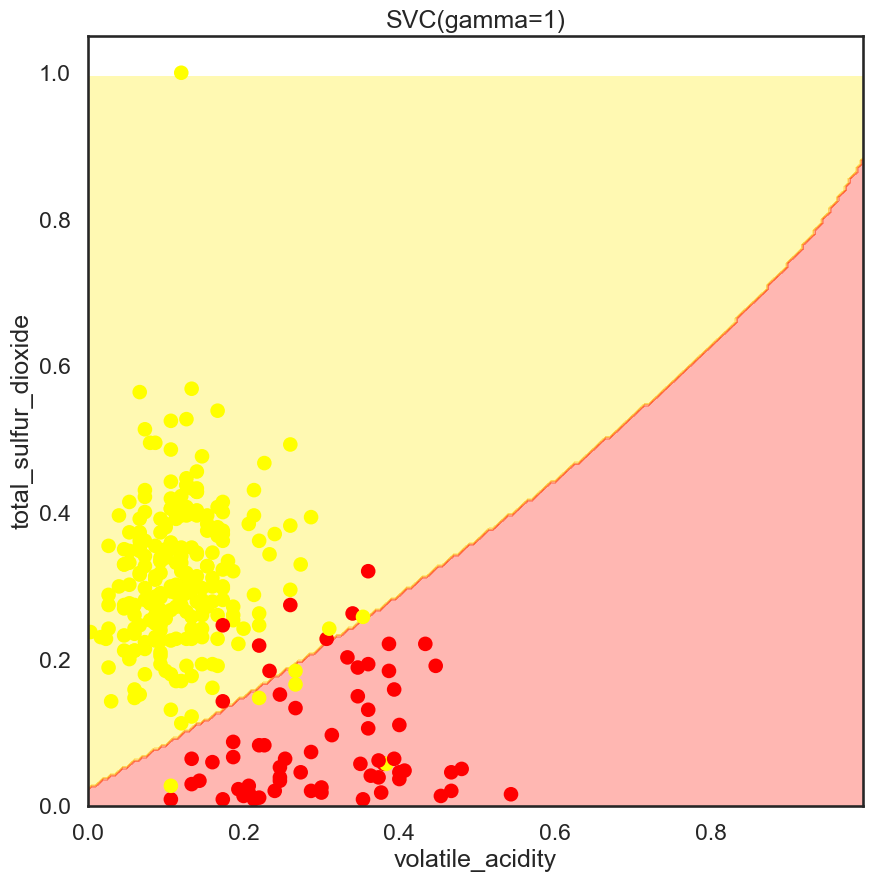

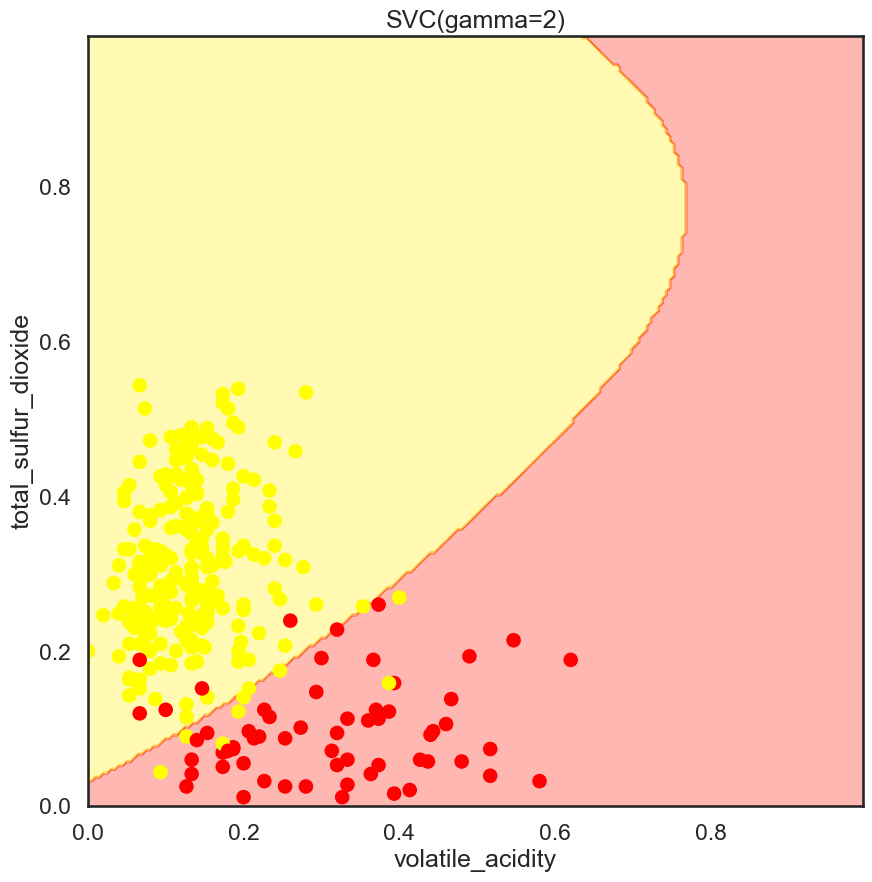

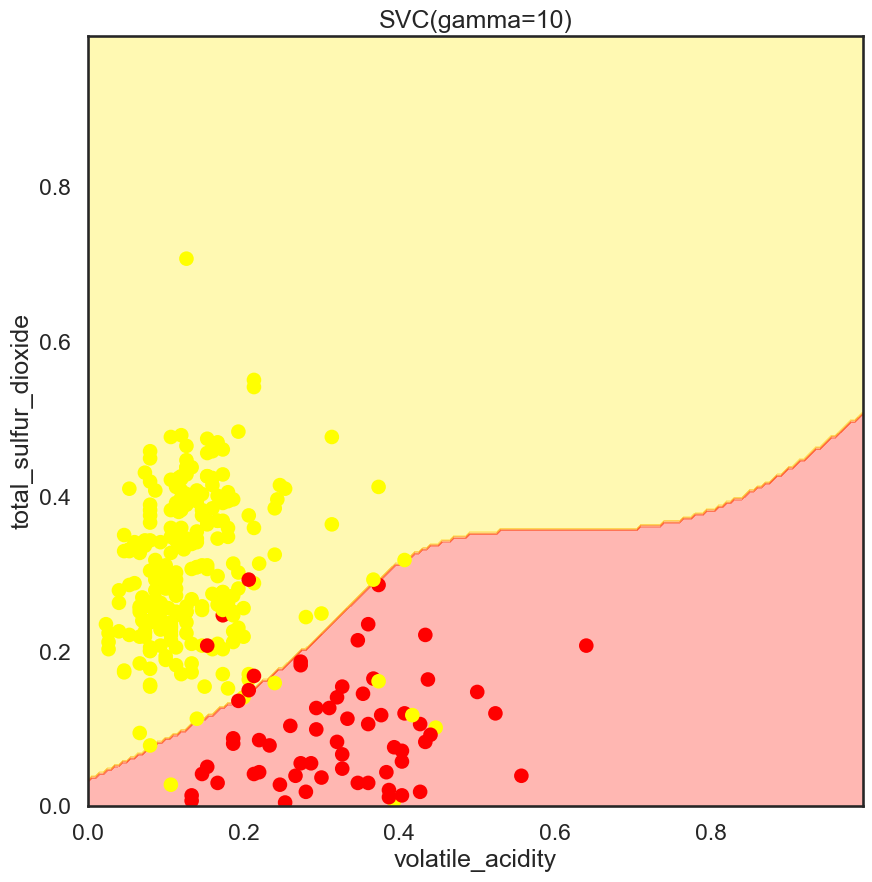

In [11]:
from sklearn.svm import SVC

gammas = [.5, 1, 2, 10]
for gamma in gammas:
    SVC_Gaussian = SVC(kernel='rbf', gamma=gamma)
    plot_decision_boundary(SVC_Gaussian, X, y)

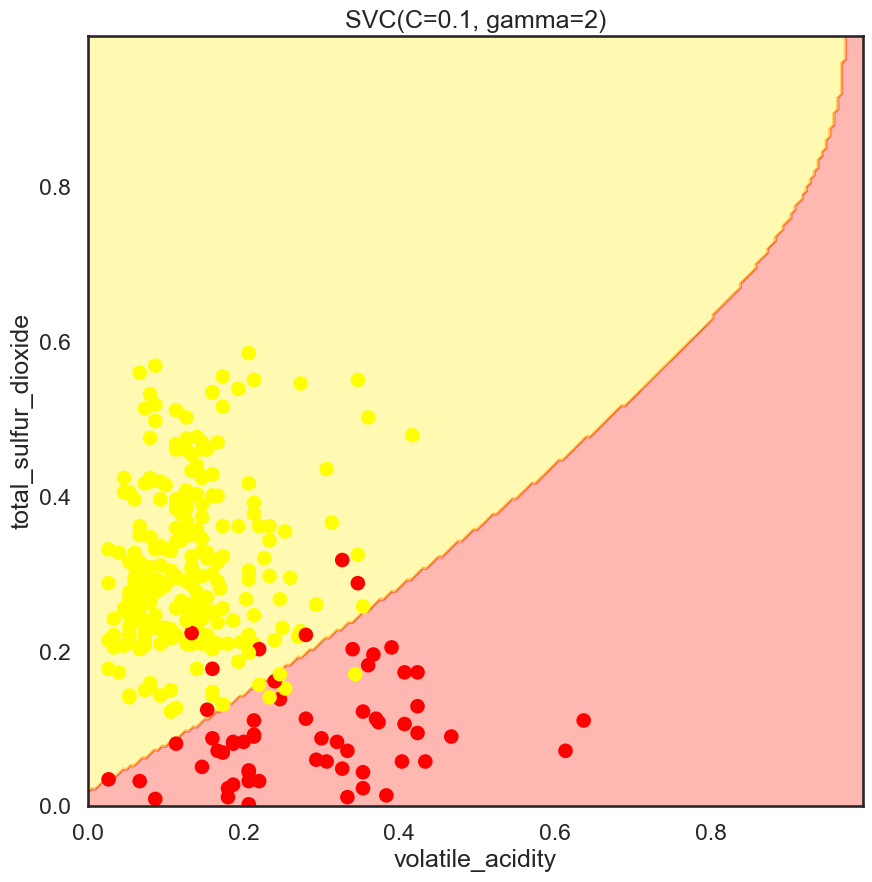

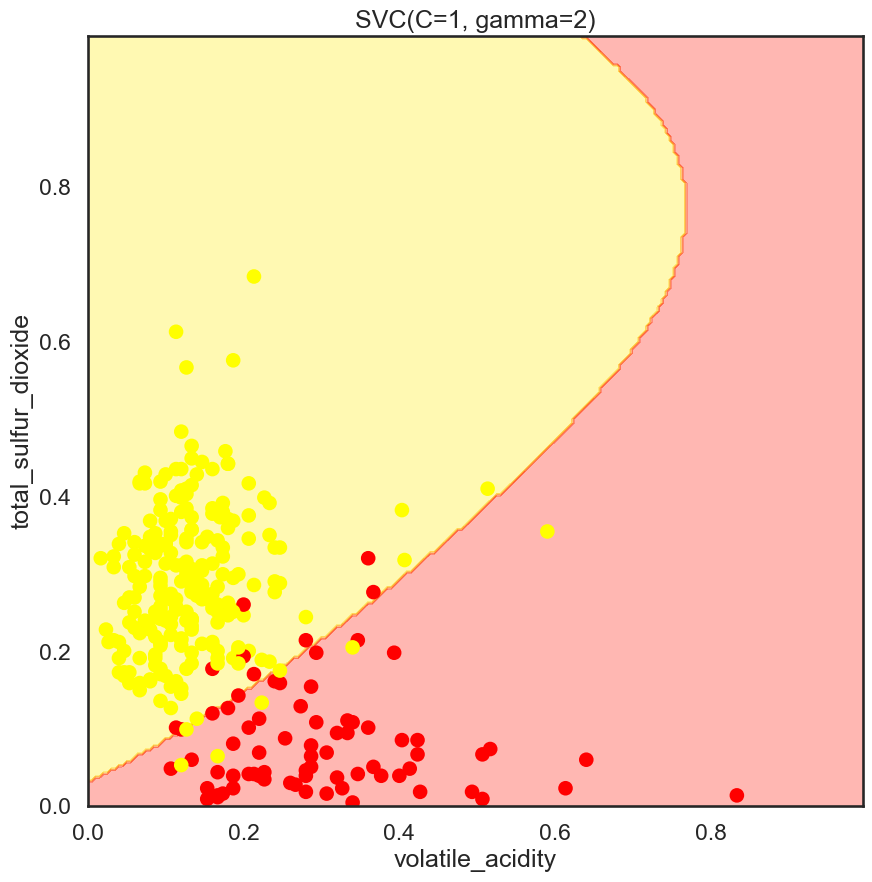

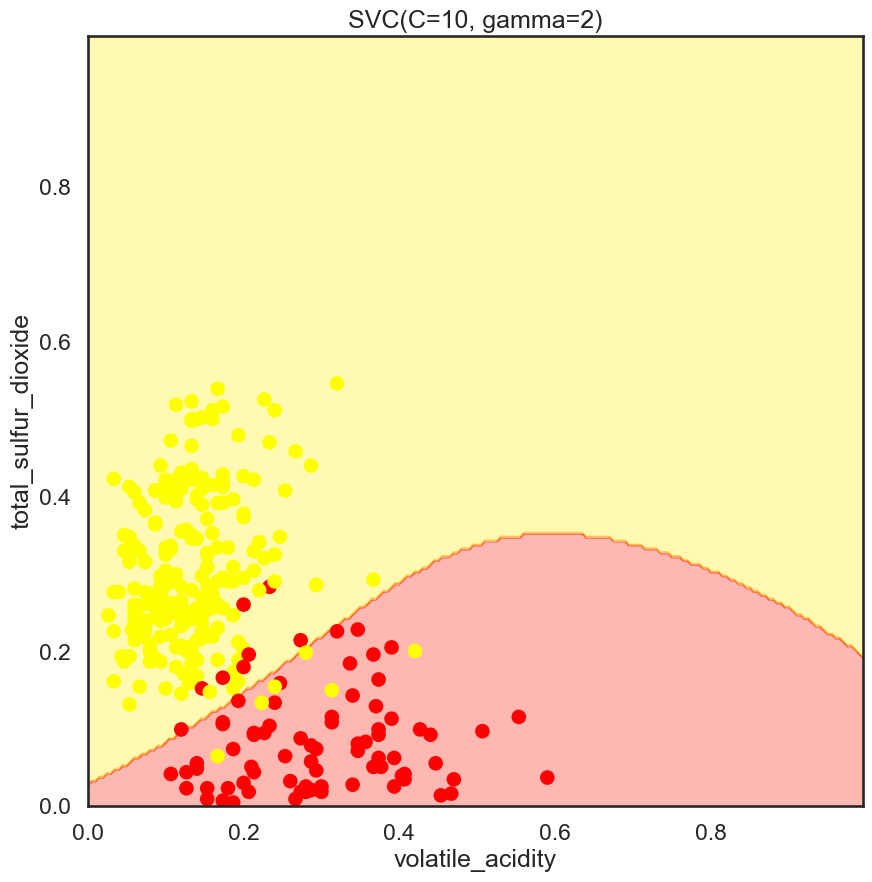

In [12]:
Cs = [.1, 1, 10]
for C in Cs:
    SVC_Gaussian = SVC(kernel='rbf', gamma=2, C=C)
    plot_decision_boundary(SVC_Gaussian, X, y)

## Part 4: Comparing Kernel Execution Times

In this exercise, we will compare the fitting times between SVC vs Nystroem with rbf kernel.  
<br><br>
Jupyter Notebooks provide a useful magic function **`%timeit`** which executes a line and prints out the time it took to fit. If we type **`%%timeit`** in the beginning of the cell, it will output the execution time.

We proceed with the following steps:
* Create `y` from data.color, and `X` from the rest of the columns.
* Use `%%timeit` to get the time for fitting an SVC with rbf kernel.
* Use `%%timeit` to get the time for the following: fit_transform the data with Nystroem and then fit a SGDClassifier.

Nystroem+SGD will take much less to fit. This difference will be more pronounced if the dataset was bigger.

* Make 5 copies of X and concatenate them
* Make 5 copies of y and concatenate them
* Compare the time it takes to fit the both methods above
🧠 背景知识
SVC with RBF kernel：

使用支持向量机的径向基核（RBF kernel），性能好但计算量大，尤其在大数据上。

sklearn.svm.SVC(kernel='rbf')

Nystroem Approximation + SGDClassifier：

Nystroem 是一种核近似方法，将非线性映射转化为线性问题。

后接 SGDClassifier，速度快，适合大数据。

In [19]:
from sklearn.kernel_approximation import Nystroem
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier

y = data.color == 'red'
X = data[data.columns[:-1]]

kwargs = {'kernel': 'rbf'}
svc = SVC(**kwargs)
nystroem = Nystroem(**kwargs)
sgd = SGDClassifier()

你这段代码是为 **SVM 的核方法对比实验** 做初始化，写得很好！我来为你逐步解释，并指出后续怎么使用这些对象来完成实验：

---

### ✅ 当前代码解析：

```python
from sklearn.kernel_approximation import Nystroem
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier
```

- 引入：
  - `SVC`：标准支持向量分类器，支持核函数（如 RBF）
  - `Nystroem`：核函数近似工具
  - `SGDClassifier`：随机梯度下降分类器，适合处理大数据量

---

```python
y = data.color == 'red'
```

- 创建标签向量 `y`：将 `'color'` 列中为 `'red'` 的标记为 `True`（1），其他为 `False`（0）

---

```python
X = data[data.columns[:-1]]
```

- 特征矩阵 `X`：选取除了最后一列（`color`）之外的所有特征

---

```python
kwargs = {'kernel': 'rbf'}
svc = SVC(**kwargs)
nystroem = Nystroem(**kwargs)
sgd = SGDClassifier()
```

- 定义超参数 `kernel='rbf'`（高斯核）
- 初始化：
  - `svc`：带 RBF 核的支持向量分类器
  - `nystroem`：同样带 RBF 核的核近似方法
  - `sgd`：随机梯度下降分类器，用于接 Nystroem 的结果



这行代码：

```python
%%timeit
svc.fit(X, y)
```

是 Jupyter Notebook 中的 **cell-level 魔法命令**，它会多次运行 `svc.fit(X, y)`，并输出**平均执行时间**和标准差，帮助你评估模型训练的性能。

---

### ✅ 它的作用是：

- **测量 `SVC` 模型在数据 `X, y` 上训练所需的时间**
- 默认执行 **7 次循环，每次循环运行代码若干次（自动决定）**
- 输出示例（运行后会看到）：

```
1 loop, best of 3: 128 ms per loop
```

或：

```
10 loops, best of 5: 23.4 ms ± 1.2 ms per loop
```

---

### 注意事项：

1. **模型会被重新训练多次**，所以如果你后续需要用 `svc` 做预测，建议再训练一次：

   ```python
   svc.fit(X, y)
   ```

2. **只适用于 Jupyter Notebook** 环境；如果你在普通的 Python 脚本中运行这段，会报错。

---

如果你还想比较 Nystroem + SGD 的时间，也可以配对写成：

```python
%%timeit
X_nys = nystroem.fit_transform(X)
sgd.fit(X_nys, y)
```

是否还需要我帮你整理为一个完整的对比函数或 Notebook cell？

In [20]:
%%timeit
svc.fit(X, y)

289 ms ± 12.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [21]:
%%timeit
X_transformed = nystroem.fit_transform(X)
sgd.fit(X_transformed, y)

49.9 ms ± 2.13 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [22]:
X2 = pd.concat([X]*5)
y2 = pd.concat([y]*5)

print(X2.shape)
print(y2.shape)

(32485, 12)
(32485,)


你这段代码是在 **构造更大的数据集（扩大5倍）**，用于测试模型在大数据量下的训练性能。

---

### 🔍 代码解释：

```python
X2 = pd.concat([X]*5)
y2 = pd.concat([y]*5)
```

- `pd.concat([X]*5)`：将 `X` 重复 5 次纵向拼接（按行拼接）
- 同理，`y2` 是将标签 `y` 也重复 5 次

---

### 🧪 输出维度：

```python
print(X2.shape)
print(y2.shape)
```

- 输出 `X2` 的行数应该是原来 `X` 的 5 倍
- 输出 `y2` 的长度也应一致
- 举例：如果 `X.shape = (1000, 4)`，则输出：

```
(5000, 4)
(5000,)
```

---

这一步是你接下来使用 `%timeit` 测试放大数据集性能的前提。

是否要继续比较 `svc.fit(X2, y2)` 和 `nystroem + sgd` 的时间？我可以直接写好两条 `%timeit` cell 给你。

In [23]:
%timeit svc.fit(X2, y2)

7.02 s ± 114 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [24]:
%%timeit
X2_transformed = nystroem.fit_transform(X2)
sgd.fit(X2_transformed, y2)

190 ms ± 3.33 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)




- `%%timeit` 会多次拟合模型。运行完之后，如果你还需要 `svc` 或 `sgd` 做预测，**请重新 fit 一次**，因为 `%timeit` 的输出不会保留模型状态。
- 如果你看到 `SVC` 在大数据集上特别慢，那是正常的——`SVC` 的复杂度大约是 **O(n²~n³)**，而 `Nystroem + SGD` 更接近线性。

---

要不要我给你写个对比输出结果的总结函数，比如自动显示两者的平均时间差异？

---
### Machine Learning Foundation (C) 2020 IBM Corporation
